<a href="https://www.kaggle.com/code/pavankumar960/supermarket-sales-analysis-kpis?scriptVersionId=309722068" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Business Objective

This analysis aims to understand sales, shipping efficiency, and profit trends across regions, product categories, and customer segments to help improve business decisions and profitability.


## Table of Contents

1. [Business Objective](#Busines-Objective)
2. [Importing Libraries](#Importing-Libraries)
3. [Data Loading](#Data-Loading)
4. [Data Preprocessing](#Data-Preprocessing)
5. [Data Cleaning](#Data-Cleaning)
6. [Feature Engineering](#Feature-Engineering)
7. [Exploratory Data Analysis (EDA)](#Exploratory-Data-Analysis-(EDA))
9. [Conclusion](#Conclusion)




# Importing Libraries

In [1]:
import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import plotly.express as px

pd.set_option('display.float_format', '{:,.2f}'.format)

import warnings
warnings.filterwarnings("ignore")

# Data Loading

In [2]:
df = pd.read_excel("/kaggle/input/supermarket-dataset/().xlsx", parse_dates=['Order Date','Ship Date'])

# Data Preprocessing

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Category           9994 non-null   object        
 1   City               9994 non-null   object        
 2   Country            9994 non-null   object        
 3   Customer Name      9994 non-null   object        
 4   Manufacturer       9994 non-null   object        
 5   Order Date         9994 non-null   datetime64[ns]
 6   Order ID           9994 non-null   object        
 7   Postal Code        9994 non-null   int64         
 8   Product Name       9994 non-null   object        
 9   Region             9994 non-null   object        
 10  Segment            9994 non-null   object        
 11  Ship Date          9994 non-null   datetime64[ns]
 12  Ship Mode          9994 non-null   object        
 13  State              9994 non-null   object        
 14  Sub-Cate

In [4]:
df.head()

,Category,City,Country,Customer Name,Manufacturer,Order Date,Order ID,Postal Code,Product Name,Region,...,Ship Date,Ship Mode,State,Sub-Category,Discount,Number of Records,Profit,Profit Ratio,Quantity,Sales
0,Office Supplies,Houston,United States,Darren Powers,Message Book,2013-01-03,CA-2011-103800,77095,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",Central,...,2013-01-07,Standard Class,Texas,Paper,0.20,1,$6,0.34,2,$16
1,Office Supplies,Naperville,United States,Phillina Ober,Avery,2013-01-04,CA-2011-112326,60540,Avery 508,Central,...,2013-01-08,Standard Class,Illinois,Labels,0.20,1,$4,0.36,3,$12
2,Office Supplies,Naperville,United States,Phillina Ober,SAFCO,2013-01-04,CA-2011-112326,60540,SAFCO Boltless Steel Shelving,Central,...,2013-01-08,Standard Class,Illinois,Storage,0.20,1,-$65,-0.24,3,$273
3,Office Supplies,Naperville,United States,Phillina Ober,GBC,2013-01-04,CA-2011-112326,60540,GBC Standard Plastic Binding Systems Combs,Central,...,2013-01-08,Standard Class,Illinois,Binders,0.80,1,-$5,-1.55,2,$4
4,Office Supplies,Philadelphia,United States,Mick Brown,Avery,2013-01-05,CA-2011-141817,19143,Avery Hi-Liter EverBold Pen Style Fluorescent ...,East,...,2013-01-12,Standard Class,Pennsylvania,Art,0.20,1,$5,0.25,3,$20


In [5]:
# Converting Object type to Float for Sales and Profit

for col in ['Profit','Sales']:
    df[col] = (
        df[col]
          .str.replace('[\$,]', '', regex=True)
          .astype(float)
    )

In [6]:
df.describe()

,Order Date,Postal Code,Ship Date,Discount,Number of Records,Profit,Profit Ratio,Quantity,Sales
count,9994,"9,994.00",9994,"9,994.00","9,994.00","9,994.00","9,994.00","9,994.00","9,994.00"
mean,2015-05-01 00:07:12.259355648,"55,190.38",2015-05-04 23:06:58.571142656,0.16,1.00,28.65,0.12,3.79,229.87
min,2013-01-03 00:00:00,"1,040.00",2013-01-07 00:00:00,0.00,1.00,"-6,600.00",-2.75,1.00,0.00
25%,2014-05-23 00:00:00,"23,223.00",2014-05-27 00:00:00,0.00,1.00,2.00,0.07,2.00,17.00
50%,2015-06-27 00:00:00,"56,430.50",2015-06-30 00:00:00,0.20,1.00,9.00,0.27,3.00,54.50
75%,2016-05-14 00:00:00,"90,008.00",2016-05-18 00:00:00,0.20,1.00,29.00,0.36,5.00,210.00
max,2016-12-30 00:00:00,"99,301.00",2017-01-05 00:00:00,0.80,1.00,"8,400.00",0.50,14.00,"22,638.00"
std,NaN,"32,063.69",NaN,0.21,0.00,234.26,0.47,2.23,623.25


# Data Cleaning

In [7]:
# checking for Nulls

df.isnull().sum()

Category             0
City                 0
Country              0
Customer Name        0
Manufacturer         0
Order Date           0
Order ID             0
Postal Code          0
Product Name         0
Region               0
Segment              0
Ship Date            0
Ship Mode            0
State                0
Sub-Category         0
Discount             0
Number of Records    0
Profit               0
Profit Ratio         0
Quantity             0
Sales                0
dtype: int64

In [8]:
# Checking for Duplicates

df[df.duplicated(keep=False)]

,Category,City,Country,Customer Name,Manufacturer,Order Date,Order ID,Postal Code,Product Name,Region,...,Ship Date,Ship Mode,State,Sub-Category,Discount,Number of Records,Profit,Profit Ratio,Quantity,Sales
384,Furniture,Columbus,United States,Laurel Beltran,Global,2013-04-23,US-2011-150119,43229,Global Leather Highback Executive Chair with P...,East,...,2013-04-27,Standard Class,Ohio,Chairs,0.30,1,-12.00,-0.04,2,281.00
385,Furniture,Columbus,United States,Laurel Beltran,Global,2013-04-23,US-2011-150119,43229,Global Leather Highback Executive Chair with P...,East,...,2013-04-27,Standard Class,Ohio,Chairs,0.30,1,-12.00,-0.04,2,281.00


In [9]:
df = df.drop_duplicates()

# Feature Engineering

In [10]:
df['Profit per Unit'] = df['Profit'].astype(float) / df['Quantity']

In [11]:
df['Sales per Unit'] = df['Sales'].astype(float) / df['Quantity']

In [12]:
df['Has Discount'] = df['Discount'].apply(lambda x: 1 if x > 0 else 0)

In [13]:
df['Profit Category'] = df['Profit'].astype(float).apply(lambda x: 'High Profit' if x > 100 else ('Loss' if x < 0 else 'Low Profit'))

In [14]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

In [15]:
df['Delivery Day'] = df['Ship Date'].dt.day_name()
df['Weekend Delivery'] = df['Delivery Day'].isin(['Saturday', 'Sunday'])

In [16]:
df['Order Value'] = df['Sales'].astype(float) * (1 - df['Discount'])

In [17]:
customer_counts = df['Customer Name'].value_counts()
df['Customer Frequency'] = df['Customer Name'].map(customer_counts)

In [18]:
region_profit = df.groupby('Region')['Profit Ratio'].mean()
df['Region Profit Avg'] = df['Region'].map(region_profit)

In [19]:
df.describe()

,Order Date,Postal Code,Ship Date,Discount,Number of Records,Profit,Profit Ratio,Quantity,Sales,Profit per Unit,Sales per Unit,Has Discount,Order Month,Order Year,Order Value,Customer Frequency,Region Profit Avg
count,9993,"9,993.00",9993,"9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00","9,993.00"
mean,2015-05-01 01:53:33.089162496,"55,191.58",2015-05-05 00:53:19.039327488,0.16,1.00,28.66,0.12,3.79,229.87,7.80,60.92,0.52,7.81,"2,014.72",197.59,15.69,0.12
min,2013-01-03 00:00:00,"1,040.00",2013-01-07 00:00:00,0.00,1.00,"-6,600.00",-2.75,1.00,0.00,"-1,320.00",0.00,0.00,1.00,"2,013.00",0.00,1.00,-0.10
25%,2014-05-23 00:00:00,"23,223.00",2014-05-27 00:00:00,0.00,1.00,2.00,0.07,2.00,17.00,0.67,5.50,0.00,5.00,"2,014.00",14.40,11.00,0.16
50%,2015-06-27 00:00:00,"56,560.00",2015-06-30 00:00:00,0.20,1.00,9.00,0.27,3.00,54.00,2.75,16.25,1.00,9.00,"2,015.00",46.00,15.00,0.17
75%,2016-05-14 00:00:00,"90,008.00",2016-05-18 00:00:00,0.20,1.00,29.00,0.36,5.00,210.00,8.75,64.00,1.00,11.00,"2,016.00",180.00,20.00,0.22
max,2016-12-30 00:00:00,"99,301.00",2017-01-05 00:00:00,0.80,1.00,"8,400.00",0.50,14.00,"22,638.00","1,680.00","3,773.00",1.00,12.00,"2,016.00","17,500.00",37.00,0.22
std,NaN,"32,065.07",NaN,0.21,0.00,234.27,0.47,2.23,623.28,56.08,142.94,0.50,3.29,1.12,539.08,6.65,0.13


# Exploratory Data Analysis (EDA)

In [20]:
# Key Performance Indicators

kpi = pd.DataFrame({
    'Total Sales': [df['Sales'].sum()],
    'Total Profit': [df['Profit'].sum()],
    'Overall Profit %': [df['Profit'].sum() / df['Sales'].sum() * 100],
    'Orders': [df['Order ID'].nunique()],
    'Customers': [df['Customer Name'].nunique()],
    'Products': [df['Product Name'].nunique()]
})
kpi.T.rename(columns={0:'Value'})


,Value
Total Sales,"2,297,073.00"
Total Profit,"286,359.00"
Overall Profit %,12.47
Orders,"5,009.00"
Customers,793.00
Products,"1,850.00"


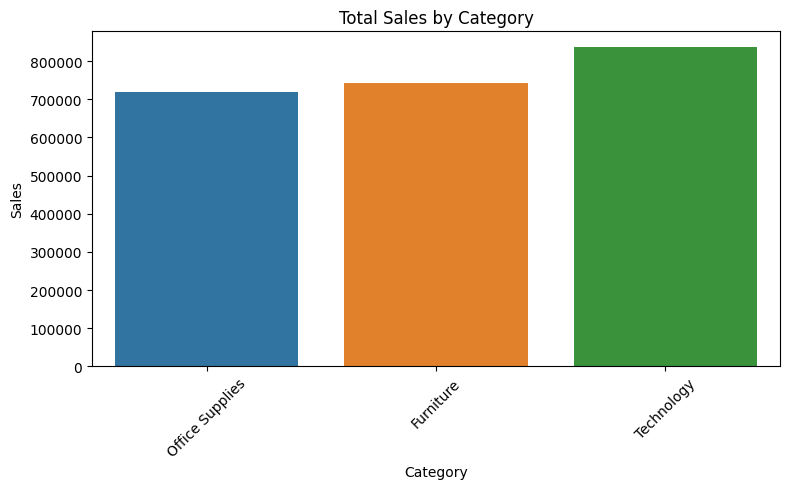

In [21]:
# Total Sales by Category

plt.figure(figsize=(8,5))
sns.barplot(data=df, x='Category', y='Sales', estimator=sum, ci=None)
plt.title("Total Sales by Category")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

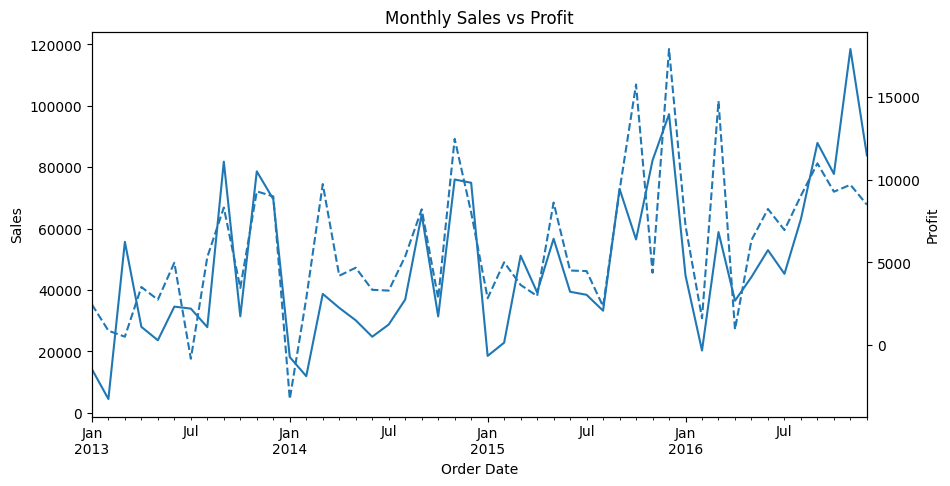

In [22]:
# Timeline of Monthly Sales and Profit

ts = (df.set_index('Order Date').resample('M').agg({'Sales':'sum','Profit':'sum'}))

fig, ax1 = plt.subplots(figsize=(10,5))
ts['Sales'].plot(ax=ax1)
ax2 = ax1.twinx()
ts['Profit'].plot(ax=ax2, linestyle='--')
ax1.set_title('Monthly Sales vs Profit')
ax1.set_ylabel('Sales')
ax2.set_ylabel('Profit')
plt.show()

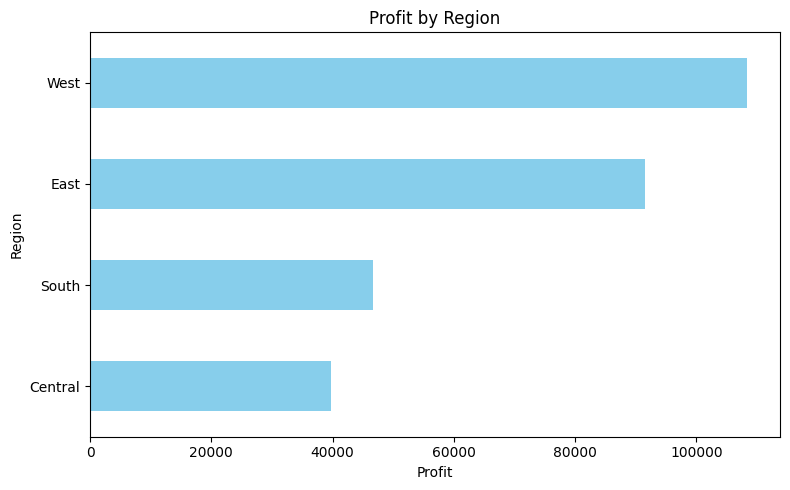

In [23]:
# profit by Region

region_profit = df.groupby('Region')['Profit'].sum().sort_values()

plt.figure(figsize=(8,5))
region_profit.plot(kind='barh', color='skyblue')
plt.title("Profit by Region")
plt.xlabel("Profit")
plt.tight_layout()
plt.show()


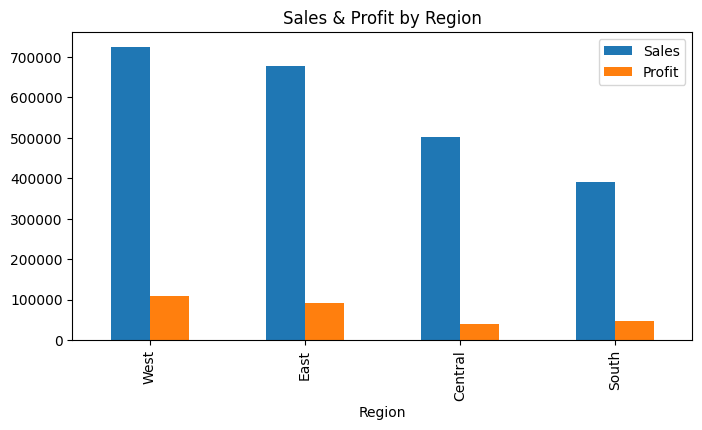

In [24]:
# Sales by Region

region = (df.groupby('Region')
            .agg(Sales=('Sales','sum'),
                 Profit=('Profit','sum'),
                 Orders=('Order ID','nunique'))
            .sort_values('Sales', ascending=False))

region.plot(kind='bar', y=['Sales','Profit'], figsize=(8,4))
plt.title('Sales & Profit by Region')
plt.show()


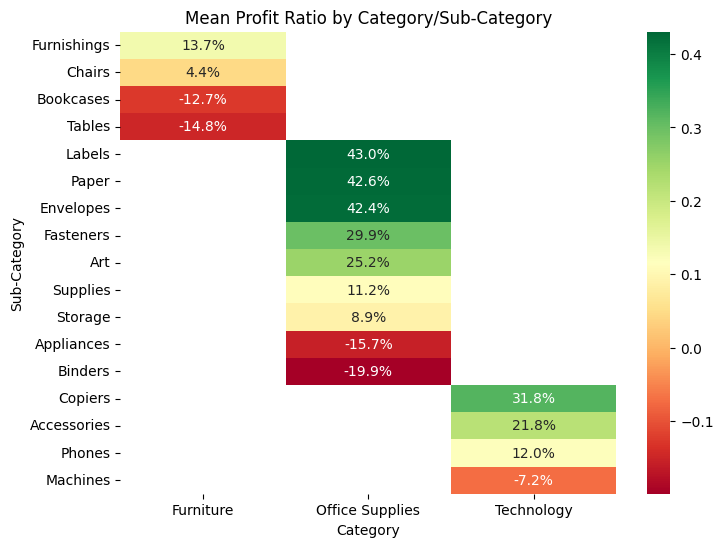

In [25]:
# Average Profit Ratio by Category

pivot = df.pivot_table(index='Sub-Category',
                       columns='Category',
                       values='Profit Ratio',
                       aggfunc='mean')

pivot = pivot.sort_values(by=list(pivot.columns), ascending=False)

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, fmt='.1%', cmap='RdYlGn')
plt.title('Mean Profit Ratio by Category/Sub-Category')
plt.show()


In [26]:
# Sales vs Profit Bubble Chart

fig = px.scatter(df, x='Sales', y='Profit', size='Quantity', color='Category',
                 hover_data=['Sub-Category', 'City', 'State'])
fig.update_layout(title="Sales vs Profit Bubble Chart")
fig.show()


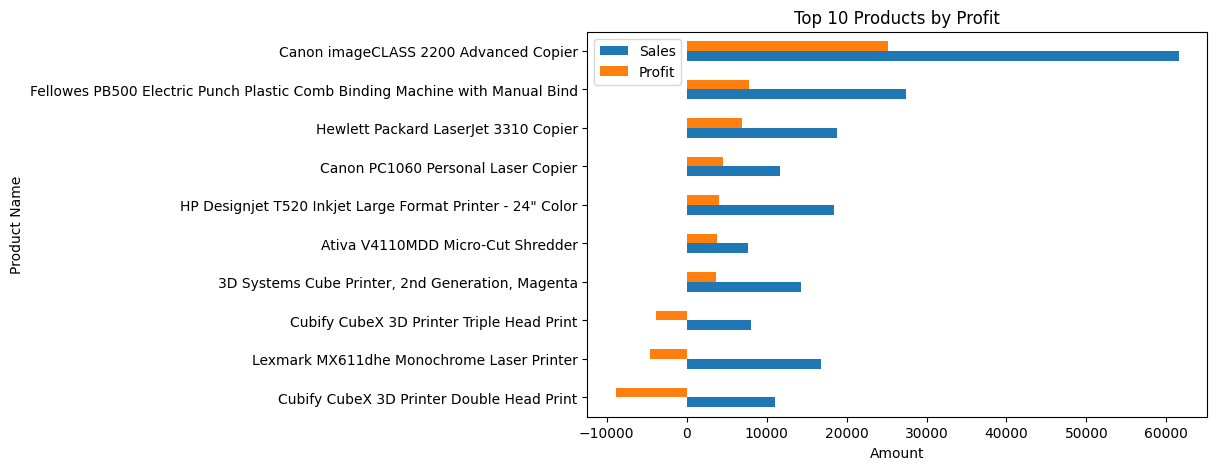

In [27]:
prod = (df.groupby('Product Name')
          .agg({'Sales':'sum','Profit':'sum'})
          .assign(abs_profit=lambda x: x['Profit'].abs())
          .sort_values('abs_profit', ascending=False)
          .head(10)
          .sort_values('Profit'))

prod[['Sales','Profit']].plot(kind='barh', figsize=(8,5))
plt.title('Top 10 Products by Profit')
plt.xlabel('Amount')
plt.show()


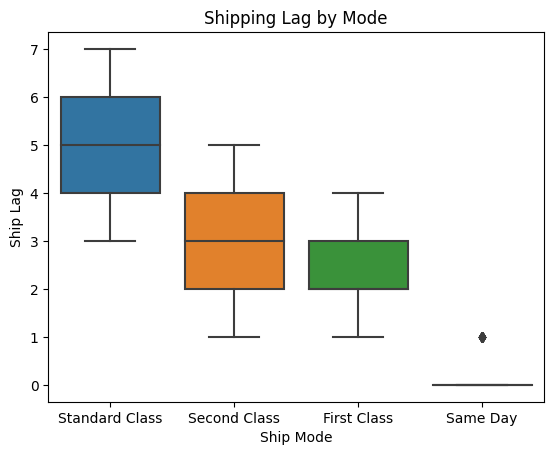

In [28]:
df['Ship Lag'] = (df['Ship Date'] - df['Order Date']).dt.days
sns.boxplot(x='Ship Mode', y='Ship Lag', data=df)
plt.title('Shipping Lag by Mode')
plt.show()


In [29]:
fig = px.sunburst(df,
                  path=['Region','Category','Sub-Category'],
                  values='Sales',
                  color='Profit',
                  color_continuous_scale='RdYlGn',
                  title='Sales hierarchy')
fig.show()


# Conclusion

- The dataset contains supermarket sales records from 2013 to 2016 in the United States.

- The overall profit margin is 12.46%.

- West and East regions contribute the most to the overall profit, while Central and South regions account for most of the losses, primarily from the Machines sub-category.

- Within the Furniture category, Chairs and Furnishings are profitable, whereas Bookcases and Tables result in losses.

- In Office Supplies, Labels, Paper, and Envelopes yield high profits, while Binders and Appliances underperform.

- For Technology, Copiers are highly profitable, while Machines lead to significant losses.